In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from sklearn.metrics import roc_auc_score


In [2]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train = x_train.astype("float32") / 255.
x_test  = x_test.astype("float32") / 255.

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

print(x_train.shape, x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
(60000, 28, 28, 1) (10000, 28, 28, 1)


In [3]:
#using 0 as normal and other as anamoly
normal_class = 0

x_train_normal = x_train[y_train == normal_class]


x_test_normal   = x_test[y_test == normal_class]
x_test_anomaly  = x_test[y_test != normal_class]

print("Train normal:", x_train_normal.shape)
print("Test normal:", x_test_normal.shape)
print("Test anomaly:", x_test_anomaly.shape)


Train normal: (5923, 28, 28, 1)
Test normal: (980, 28, 28, 1)
Test anomaly: (9020, 28, 28, 1)


In [5]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Flatten()(input_img)
encoded = Dense(64, activation='relu')(x)

# Decoder
x = Dense(28*28, activation='sigmoid')(encoded)
decoded = Reshape((28, 28, 1))(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = autoencoder.fit(
    x_train_normal,
    x_train_normal,
    epochs=20,
    batch_size=128,
    validation_data=(x_test_normal, x_test_normal)
)


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1589 - val_loss: 0.0535
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0491 - val_loss: 0.0387
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0374 - val_loss: 0.0340
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0330 - val_loss: 0.0303
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0292 - val_loss: 0.0269
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0261 - val_loss: 0.0241
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0231 - val_loss: 0.0215
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0206 - val_loss: 0.0194
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0188 - val_loss: 0.0178
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0173 - val_loss: 0.0166
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0160 - val_loss: 0.0157
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0150 - val_l

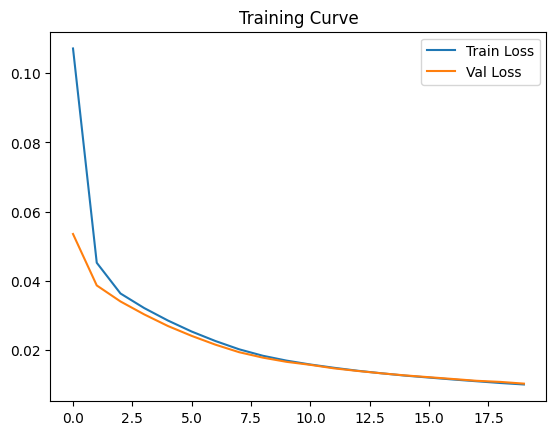

In [7]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Training Curve")
plt.show()


In [8]:
# Reconstruct samples
recon_normal  = autoencoder.predict(x_test_normal)
recon_anomaly = autoencoder.predict(x_test_anomaly)

# Compute MSE
normal_err  = np.mean((x_test_normal  - recon_normal)**2, axis=(1,2,3))
anomaly_err = np.mean((x_test_anomaly - recon_anomaly)**2, axis=(1,2,3))

print("Normal Error Mean:", np.mean(normal_err))
print("Anomaly Error Mean:", np.mean(anomaly_err))


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Normal Error Mean: 0.01027385
Anomaly Error Mean: 0.04208533


In [9]:
threshold = normal_err.mean() + 3*normal_err.std()
threshold


np.float32(0.027284253)

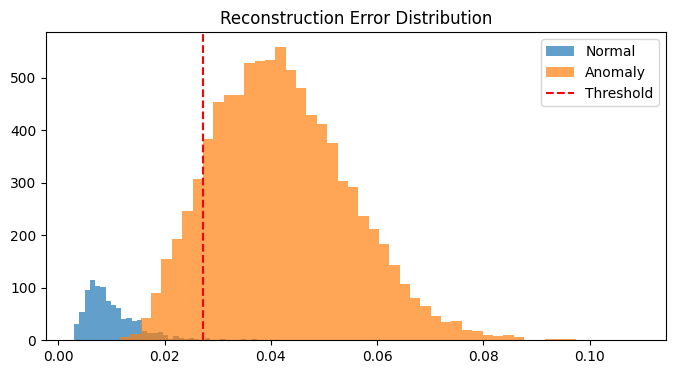

In [10]:
plt.figure(figsize=(8,4))
plt.hist(normal_err, bins=50, alpha=0.7, label="Normal")
plt.hist(anomaly_err, bins=50, alpha=0.7, label="Anomaly")
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()


In [11]:
y_true  = np.array([0]*len(normal_err) + [1]*len(anomaly_err))
y_score = np.concatenate([normal_err, anomaly_err])

auc = roc_auc_score(y_true, y_score)
print("AUC Score:", auc)

y_pred = (y_score > threshold).astype(int)

acc = np.mean(y_pred == y_true)
print("Detection Accuracy:", acc)


AUC Score: 0.9914847956921128
Detection Accuracy: 0.8904


Normal samples:


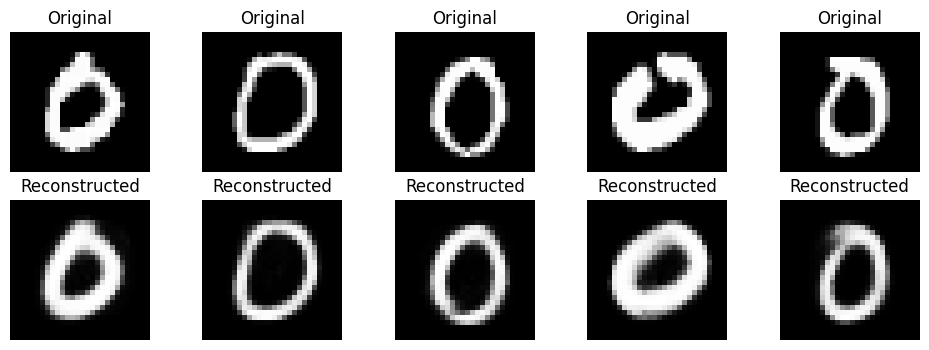

Anomaly samples:


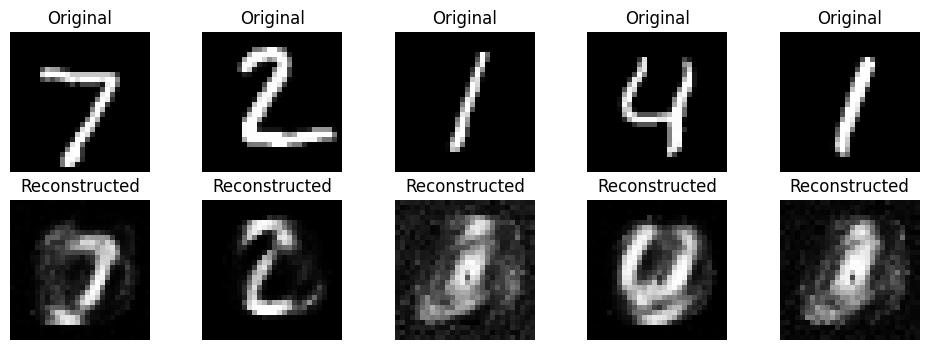

In [12]:
def show_reconstruction(orig, recon, n=5):
    plt.figure(figsize=(12,4))
    for i in range(n):
        # Original
        plt.subplot(2, n, i+1)
        plt.imshow(orig[i].squeeze(), cmap="gray")
        plt.title("Original")
        plt.axis("off")

        # Reconstructed
        plt.subplot(2, n, i+1+n)
        plt.imshow(recon[i].squeeze(), cmap="gray")
        plt.title("Reconstructed")
        plt.axis("off")
    plt.show()

print("Normal samples:")
show_reconstruction(x_test_normal, recon_normal)

print("Anomaly samples:")
show_reconstruction(x_test_anomaly, recon_anomaly)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


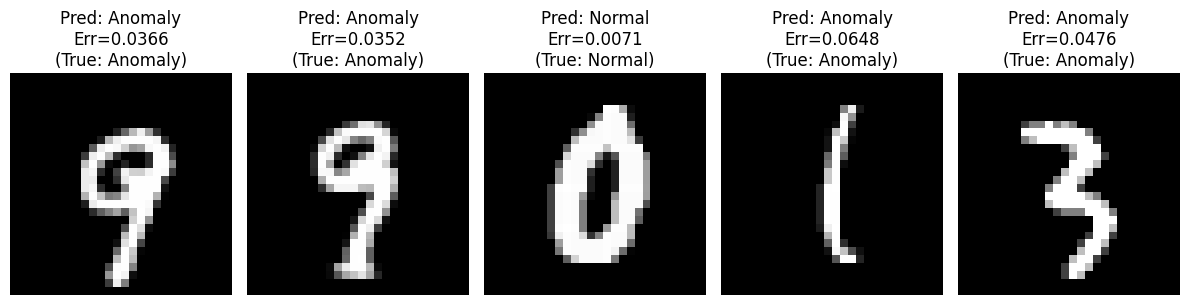

In [13]:
import random

all_images = np.concatenate([x_test_normal, x_test_anomaly])
all_labels = np.concatenate([np.zeros(len(x_test_normal)),
                             np.ones(len(x_test_anomaly))])

idxs = random.sample(range(len(all_images)), 5)

plt.figure(figsize=(12,6))

for i, idx in enumerate(idxs):
    img = all_images[idx:idx+1]
    true_label = all_labels[idx]
    recon = autoencoder.predict(img)
    err = np.mean((img - recon)**2)
    pred = 1 if err > threshold else 0

    plt.subplot(1, 5, i+1)
    plt.imshow(img.squeeze(), cmap="gray")

    title = f"Pred: {'Anomaly' if pred==1 else 'Normal'}\nErr={err:.4f}"
    title += f"\n(True: {'Anomaly' if true_label==1 else 'Normal'})"

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()
